# Baseline 1 — TF-IDF + LogisticRegression

**Purpose.** Lightweight sanity-check classifier for 27-way intent prediction on the Bitext customer-support dataset. If macro-F1 ≥ 0.80 on val, we ship it as Baseline 1.

**Design (frozen, see `configs/tfidf_config.yaml`).**
- Vectorizer: `TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True, lowercase=True)`
- Classifier: `LogisticRegression(solver='saga', C=1.0, max_iter=1000, random_state=42, n_jobs=-1)`
- Both wrapped in a single `Pipeline` so load/save is atomic (one `joblib` file).

**Reproducibility.** All training logic lives in `scripts/train_tfidf.py`. This notebook imports `run_pipeline` so the notebook and CLI produce identical artifacts.

In [1]:
# Ensure we can import scripts/ when running from notebooks/
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('REPO_ROOT =', REPO_ROOT)

REPO_ROOT = /home/mcaai/zh0038qi/customer-support-llm


In [2]:
import json
import logging

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from scripts.train_tfidf import run_pipeline, _setup_logging

_setup_logging(level=logging.INFO)
pd.set_option('display.max_colwidth', 80)

## 1. Train + evaluate (full run)

`run_pipeline` handles: load splits → fit `Pipeline` → persist checkpoint → predict val+test → compute metrics → latency → confusion matrix → error CSV → `results.json`. It writes everything under the repo root:

| Artifact | Path |
|---|---|
| Checkpoint | `checkpoints/tfidf/pipeline.joblib` |
| Results JSON | `outputs/metrics/tfidf_<YYYYMMDD>_<hash>/results.json` |
| Confusion matrix | `outputs/figures/03_tfidf_confusion_matrix.png` |
| Error CSV | `outputs/error_analysis/tfidf_errors.csv` |

In [3]:
CONFIG_PATH = REPO_ROOT / 'configs' / 'tfidf_config.yaml'

results = run_pipeline(
    config_path=CONFIG_PATH,
    repo_root=REPO_ROOT,
    smoke_test=False,
)
run_id = results['run_id']
run_id

14:27:37 | INFO    | train_tfidf | run_id=tfidf_20260418_06cce19 smoke_test=False seed=42


14:27:37 | INFO    | train_tfidf | Loading data (smoke_test=False)


14:27:37 | INFO    | train_tfidf | train=17494 val=2332 test=3500 | n_intents_train=27


14:27:37 | INFO    | train_tfidf | Fitting pipeline: Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42,
                                    solver='saga'))])


14:27:38 | INFO    | train_tfidf | Training wall-clock: 0.78 s


...

14:27:40 | INFO    | train_tfidf | Saved confusion matrix to /home/mcaai/zh0038qi/customer-support-llm/outputs/figures/03_tfidf_confusion_matrix.png


14:27:40 | INFO    | train_tfidf | Saved 26 errors to /home/mcaai/zh0038qi/customer-support-llm/outputs/error_analysis/tfidf_errors.csv


14:27:41 | INFO    | train_tfidf | Latency p50=0.763ms p95=0.787ms throughput=1307/s


14:27:41 | INFO    | train_tfidf | Saved results to /home/mcaai/zh0038qi/customer-support-llm/outputs/metrics/tfidf_20260418_06cce19/results.json


'tfidf_20260418_06cce19'

## 2. Top-line metrics (val + test)

In [4]:
val_m = results['metrics']['intent_val']
test_m = results['metrics']['intent']

summary = pd.DataFrame(
    {
        'val': [val_m['accuracy'], val_m['macro_f1'], val_m['macro_precision'], val_m['macro_recall'], val_m['weighted_f1']],
        'test': [test_m['accuracy'], test_m['macro_f1'], test_m['macro_precision'], test_m['macro_recall'], test_m['weighted_f1']],
    },
    index=['accuracy', 'macro_f1', 'macro_precision', 'macro_recall', 'weighted_f1'],
)
summary

,val,test
accuracy,0.9889,0.9926
macro_f1,0.9882,0.9922
macro_precision,0.9891,0.9927
macro_recall,0.9876,0.9919
weighted_f1,0.9888,0.9926


In [5]:
print('Run ID           :', results['run_id'])
print('Git commit       :', results['git_commit'])
print('Seed             :', results['seed'])
print('Test set hash    :', results['test_set_hash'])
print('Train wall-clock :', results['training_wallclock_seconds'], 's')
print('Latency p50/p95  :', round(results['latency']['p50_ms'], 3), '/', round(results['latency']['p95_ms'], 3), 'ms (CPU, batch=1)')
print('Checkpoint size  :', results['resources']['disk_size_mb'], 'MB')
print('Vocab size       :', results['resources']['vocab_size'])

Run ID           : tfidf_20260418_06cce19
Git commit       : 06cce19
Seed             : 42
Test set hash    : sha256:5641a8ab0fb4814b
Train wall-clock : 0.782 s
Latency p50/p95  : 0.763 / 0.787 ms (CPU, batch=1)
Checkpoint size  : 0.93 MB
Vocab size       : 4734


## 3. Per-class performance — weakest intents

In [6]:
per_class = pd.DataFrame(test_m['per_class']).T
per_class = per_class.sort_values('f1')
per_class.head(10)

,precision,recall,f1,support
check_invoice,0.9489,0.9924,0.9701,131.0
get_invoice,1.0000,0.9457,0.9721,129.0
cancel_order,1.0000,0.9577,0.9784,71.0
delete_account,0.9630,1.0000,0.9811,130.0
registration_problems,0.9787,0.9857,0.9822,140.0
create_account,0.9921,0.9766,0.9843,128.0
payment_issue,0.9929,0.9789,0.9858,142.0
change_order,0.9766,1.0000,0.9881,125.0
check_cancellation_fee,0.9779,1.0000,0.9888,133.0
track_refund,0.9808,1.0000,0.9903,102.0


## 4. Confusion matrix (normalized, test)

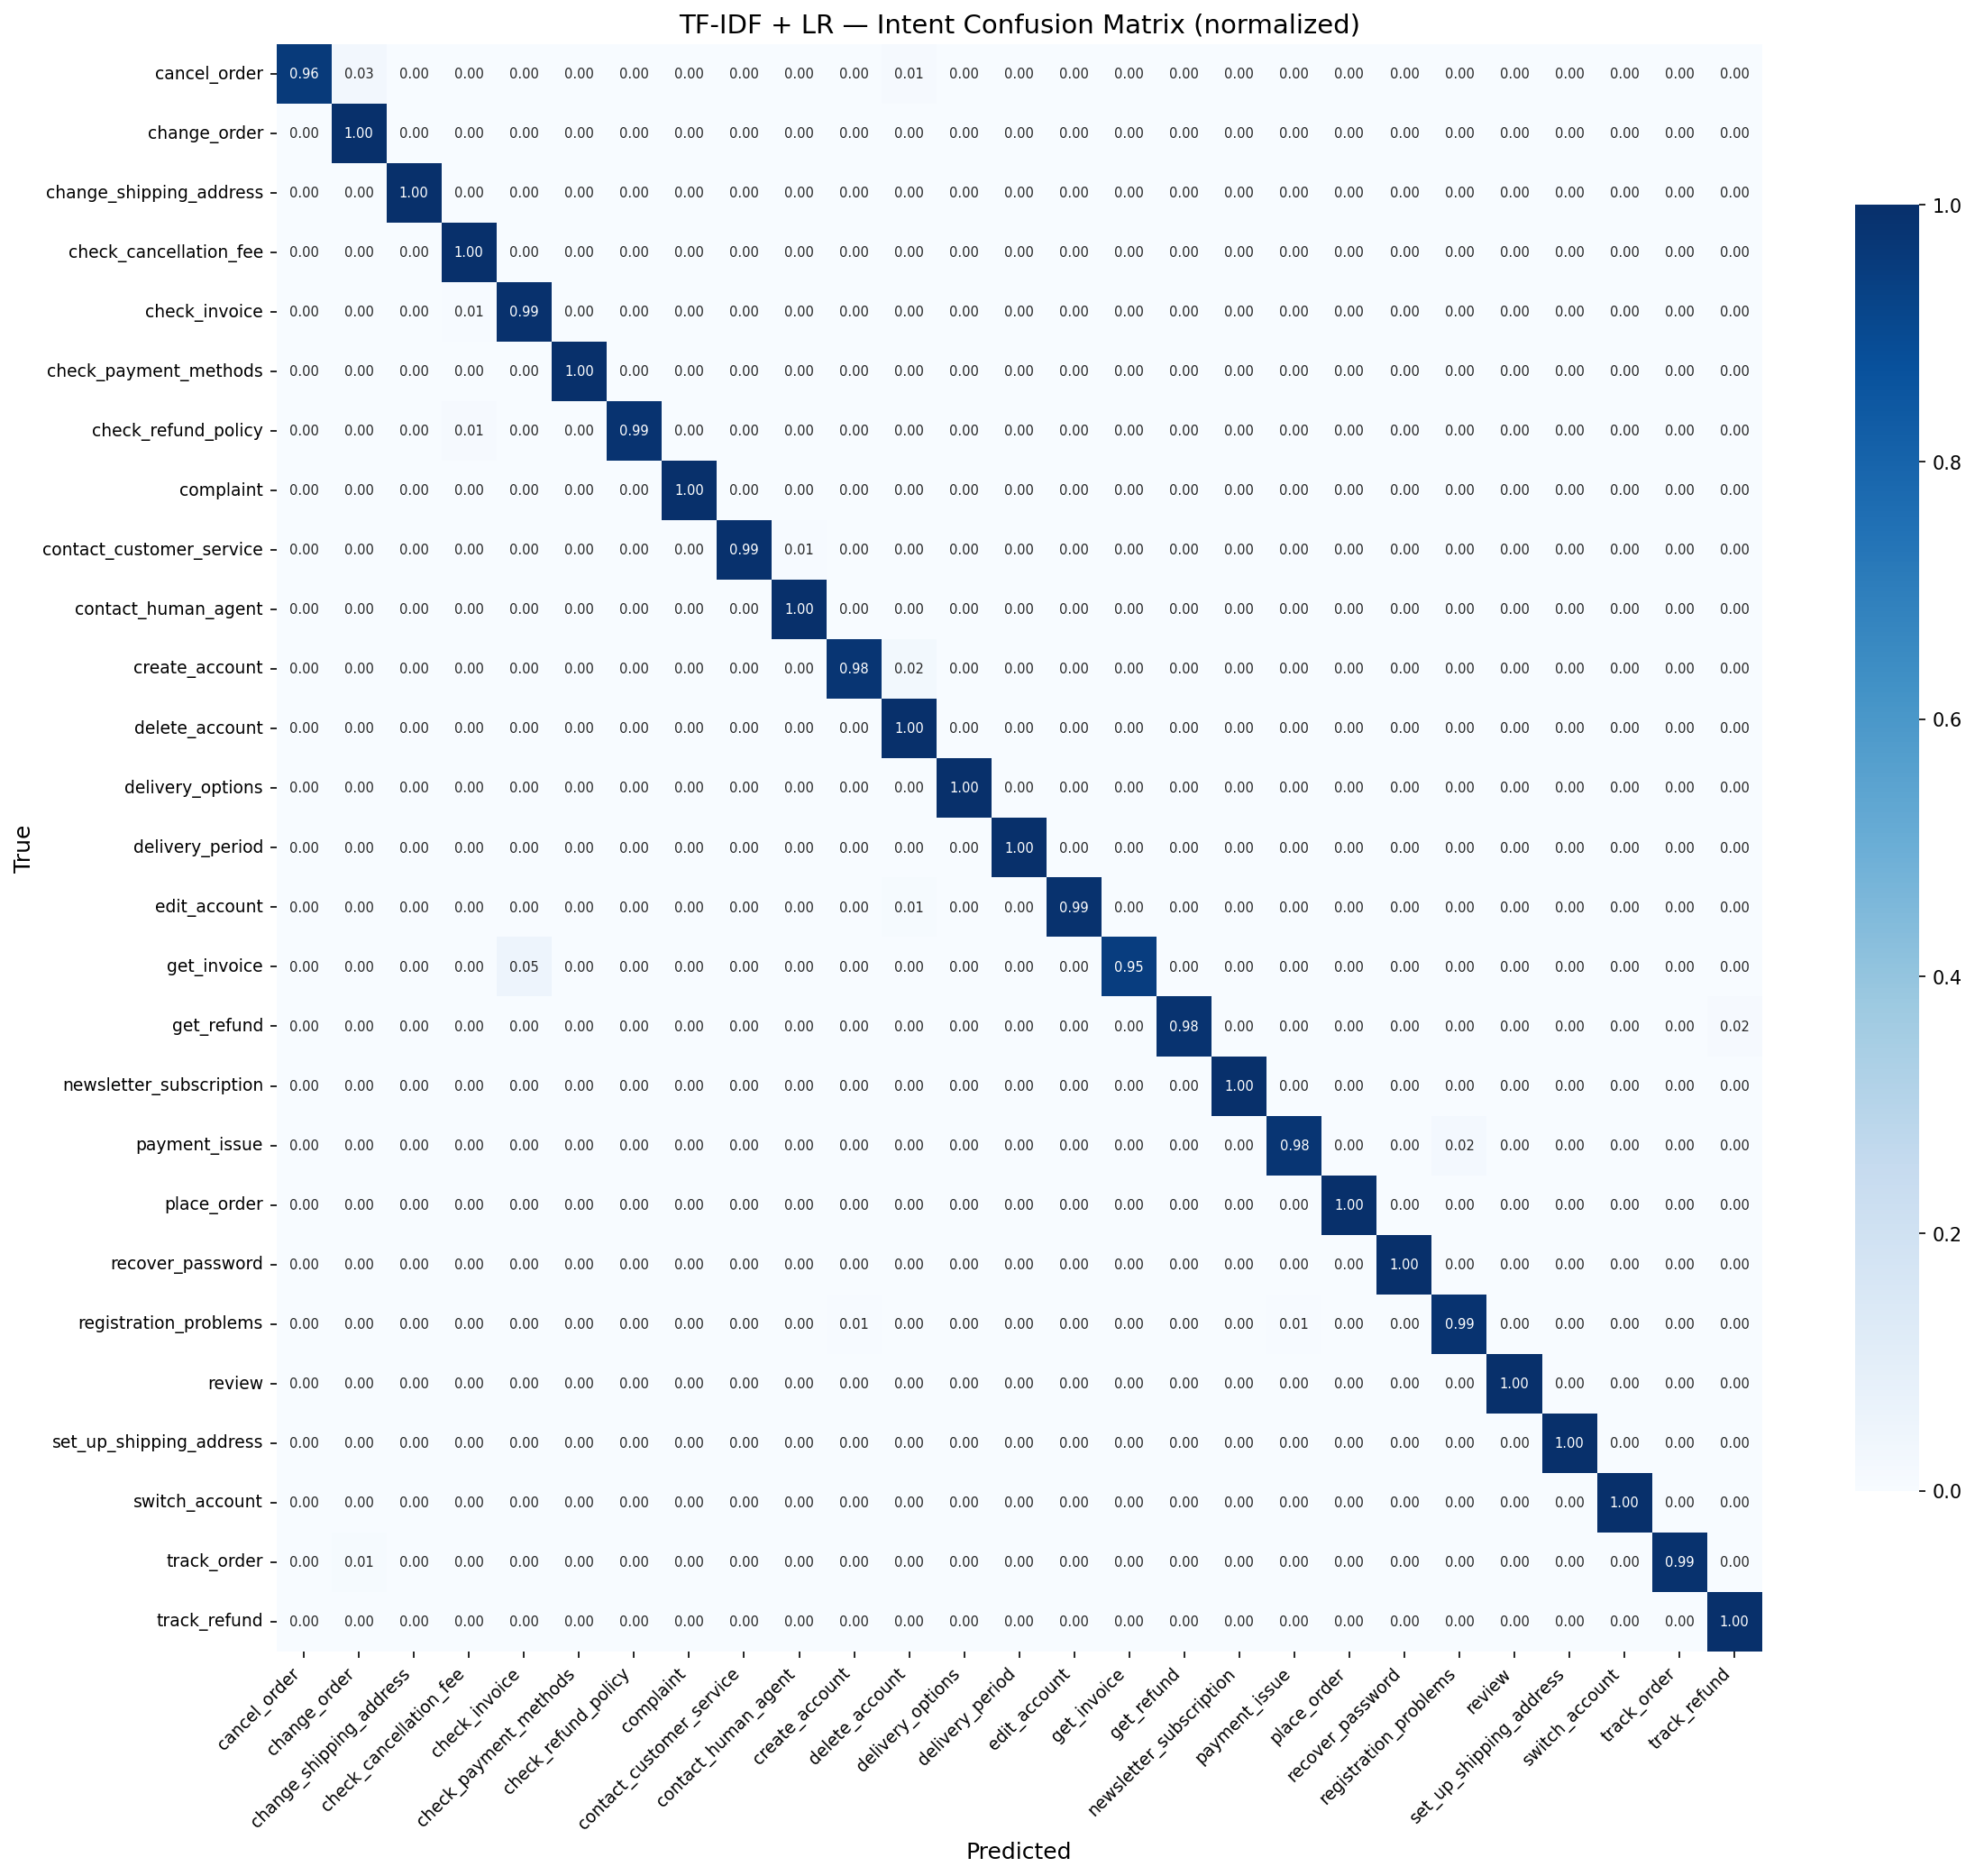

In [7]:
cm_path = REPO_ROOT / 'outputs' / 'figures' / '03_tfidf_confusion_matrix.png'
display(Image(str(cm_path)))

## 5. Error spot-check

Sample 10 misclassified test instructions to eyeball failure modes.

In [8]:
errors = pd.read_csv(REPO_ROOT / 'outputs' / 'error_analysis' / 'tfidf_errors.csv')
print(f'Total errors: {len(errors)}')
errors.sample(n=min(10, len(errors)), random_state=0)

Total errors: 26


,text,true_label,predicted_label,text_length
2,problems with cnceling purchase {{Order Number}},cancel_order,change_order,48
20,downlpoad bills from {{Person Name}},get_invoice,check_invoice,36
14,are the charges of your services refundable?,check_refund_policy,check_cancellation_fee,44
17,i want information about creatign a {{Account Category}} account,create_account,delete_account,64
5,can usend me the damn invoices from {{Person Name}},get_invoice,check_invoice,51
11,canmcel order {{Order Number}},cancel_order,change_order,30
22,I don't know how to dfownload my invoice #85632,get_invoice,check_invoice,47
13,editing {{Account Category}} account,edit_account,delete_account,36
18,I am trying to inform of an error with paymenys,payment_issue,registration_problems,47
19,trackorder {{Order Number}},track_order,change_order,27


## 6. Round-trip: reload checkpoint and predict a few examples

Confirms the persisted `Pipeline` works end-to-end after serialization.

In [9]:
pipe = joblib.load(REPO_ROOT / 'checkpoints' / 'tfidf' / 'pipeline.joblib')
examples = [
    'I need to cancel my order',
    'how do I get a refund',
    'i forgot my password',
    'where is my package',
    'please change my shipping address',
]
preds = pipe.predict(examples)
pd.DataFrame({'instruction': examples, 'predicted_intent': preds})

,instruction,predicted_intent
0,I need to cancel my order,cancel_order
1,how do I get a refund,get_refund
2,i forgot my password,recover_password
3,where is my package,delivery_period
4,please change my shipping address,change_shipping_address


## 7. Decision — ship Baseline 1?

Rule: ship if `val_macro_f1 ≥ 0.80`.


In [10]:
THRESHOLD = 0.80
ship = val_m['macro_f1'] >= THRESHOLD
print(f'val macro_f1 = {val_m["macro_f1"]:.4f}  (threshold {THRESHOLD:.2f}) -> ship? {ship}')

val macro_f1 = 0.9882  (threshold 0.80) -> ship? True
